# EDA - Coin Clustering wit KMeans



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import os


## Load Cleaned Data from Local Storage

In [2]:
INPUT_FILE = "coins_cleaned.csv"

if not os.path.exists(INPUT_FILE):
    print(f"ERROR: {INPUT_FILE} not found")
else:
    df = pd.read_csv(INPUT_FILE)
    print(f"Loaded {len(df)} records ")
    display(df.head())

Loaded 4100 records 


,id,ticker,date,open,high,low,close,volume
0,1,BTC-USD,2024-01-01,42280.234375,44175.437500,42214.976562,44167.332031,18426978443
1,2,BTC-USD,2024-01-02,44187.140625,45899.707031,44176.949219,44957.968750,39335274536
2,3,BTC-USD,2024-01-03,44961.601562,45503.242188,40813.535156,42848.175781,46342323118
3,4,BTC-USD,2024-01-04,42855.816406,44770.023438,42675.175781,44179.921875,30448091210
4,5,BTC-USD,2024-01-05,44192.980469,44353.285156,42784.718750,44162.691406,32336029347


## Average Close Price for clustering - Feature Engineering

In [13]:
cluster_data = []
tickers = df['ticker'].unique()

for ticker in tickers:
    ticker_subset = df[df['ticker'] == ticker].copy()
    
    # percentage change in daily price
    ticker_subset['daily_close'] = ticker_subset['close'].pct_change()
   
    # calculations
    mean_daily_close = ticker_subset['daily_close'].mean()
    std_daily_clos = ticker_subset['daily_close'].std()
    
    cluster_data.append({
        'ticker': ticker,
        'mean_daily_close': mean_daily_close,
        'std_daily_clos': std_daily_clos,
    })

features_df = pd.DataFrame(cluster_data).dropna()
features_df

,ticker,mean_daily_close,std_daily_clos
0,BTC-USD,0.000837,0.025884
1,ETH-USD,0.000503,0.037256
2,SOL-USD,0.000601,0.043635
3,BNB-USD,0.001223,0.028952
4,DOGE-USD,0.001251,0.050777


## KMeans Clustering
Group coins bases on - Avg Close Price, Mean Daily Close, Std Daily Close 


In [ ]:
X = features_df[['mean_daily_close', 'std_daily_clos']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# High, Mid, Low
K = 3
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
features_df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"clustering done!, with K={K}")
display(features_df)

KeyError: "['avg_close'] not in index"

## Scatter (Mean Daily Close vs Std Daily Close)
Visaulize with Std Daily Close(Volatality) against Mean Daily Close

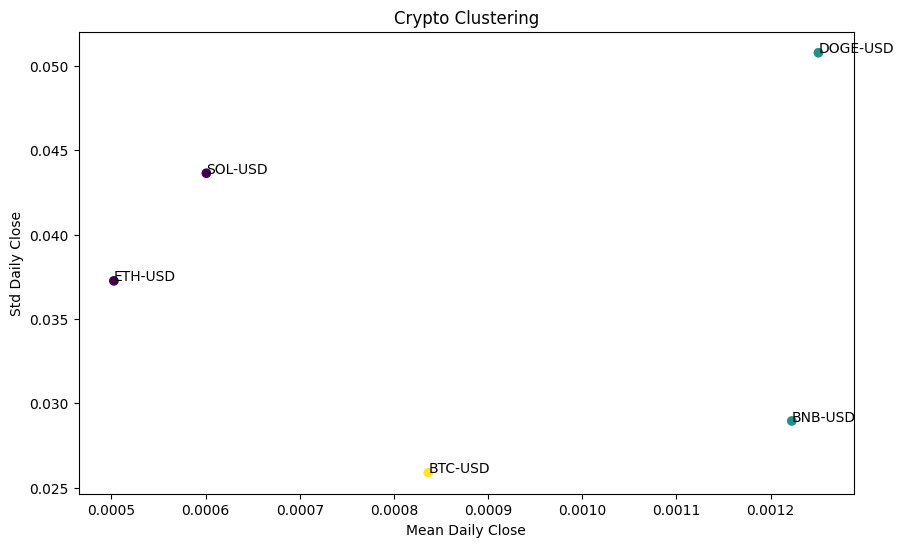

In [33]:
plt.figure(figsize=(10, 6))
plt.scatter(features_df['mean_daily_close'], features_df['std_daily_clos'], 
                    c=features_df['cluster'])

for i, ticker in enumerate(features_df['ticker']):
    plt.annotate(ticker, (features_df['mean_daily_close'].iloc[i], features_df['std_daily_clos'].iloc[i]))

plt.title(f"Crypto Clustering")
plt.xlabel('Mean Daily Close')
plt.ylabel('Std Daily Close')
plt.show()